In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family']    = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

sns.set_theme(style="whitegrid", palette="muted")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [23]:
# Carga el CSV
df = pd.read_csv("encuesta.csv")

# Eliminar columna innecesaria
df = df.drop(columns=["Marca temporal"])

# Ver encabezados restantes
for i, col in enumerate(df.columns):
    print(f"{i} → {col}")

0 → Numero de expediente
1 → Genero
2 → ¿Cuantos años tienes?
3 → ¿Que semestre estas cursando?
4 → Numero de horas que dedicas para estudiar a la semana
5 → Promedio general del ultimo semestre cursado
6 → Cantidad de materias aprobadas en el ultimo semestre cursado
7 → ¿Cuantos lenguajes de programacion sientes que dominas o con cuantos tienes experiencia y trabajas con comodidad?
8 → ¿Cuantas herramientas de IA generadoras de texto utilizas comunmente?
9 → Generalmente, ¿considera valido el uso de la inteligencia artificial generadora de texto en trabajos académicos?
10 → Aproximadamente, ¿Cuantas veces consultas a una IA generadora de texto en un dia?
11 → ¿Que herramienta de IA generadora de texto utilizas con mayor frecuencia en tus actividades académicas?
12 → ¿Como calificarías tu nivel de confianza sobre las respuestas generadas por los modelos de IA generadoras de texto?


In [24]:
df.rename(columns={
    # ── Cuantitativas discretas ─────────────────────────
    "¿Cuantos años tienes?"                                                                                                     : "edad",
    "Cantidad de materias aprobadas en el ultimo semestre cursado"                                                              : "materias_aprobadas",
    "¿Cuantas herramientas de IA generadoras de texto utilizas comunmente?"                                                     : "num_herramientas",
    "Aproximadamente, ¿Cuantas veces consultas a una IA generadora de texto en un dia?"                                         : "prompts_dia",
    "¿Cuantos lenguajes de programacion sientes que dominas o con cuantos tienes experiencia y trabajas con comodidad?"         : "num_lenguajes",

    # ── Cuantitativas continuas ─────────────────────────
    "Numero de horas que dedicas para estudiar a la semana"                                                                     : "horas_estudio",
    "Promedio general del ultimo semestre cursado"                                                                              : "promedio",

    # ── Cualitativas nominales ──────────────────────────
    "Genero"                                                                                                                    : "genero",
    "¿Que herramienta de IA generadora de texto utilizas con mayor frecuencia en tus actividades académicas?"                   : "modelo_preferido",
    "Numero de expediente"                                                                                                      : "expediente",

    # ── Cualitativas ordinales ──────────────────────────
    "¿Que semestre estas cursando?"                                                                                             : "semestre",
    "Generalmente, ¿considera valido el uso de la inteligencia artificial generadora de texto en trabajos académicos?"          : "postura_ia",
    "¿Como calificarías tu nivel de confianza sobre las respuestas generadas por los modelos de IA generadoras de texto?"       : "confianza_ia",

}, inplace=True)

print("✅ Columnas renombradas")
print(df.columns.tolist())

✅ Columnas renombradas
['expediente', 'genero', 'edad', 'semestre', 'horas_estudio', 'promedio', 'materias_aprobadas', 'num_lenguajes', 'num_herramientas', 'postura_ia', 'prompts_dia', 'modelo_preferido', 'confianza_ia']


In [25]:
print(f"Registros: {df.shape[0]} encuestados, {df.shape[1]} variables\n")
df.head()        # Ver primeras 5 filas

Registros: 6 encuestados, 13 variables



,expediente,genero,edad,semestre,horas_estudio,promedio,materias_aprobadas,num_lenguajes,num_herramientas,postura_ia,prompts_dia,modelo_preferido,confianza_ia
0,222214889,Femenino,21,7mo Semestre,2,96,3,3,2,Sí,1,ChatGPT,Regular
1,222211112,Masculino,21,8vo Semestre,5,91,5,2,3,Sí,2,Gemini,Alto
2,223203764,Masculino,26,3er Semestre,5,85,5,1,1,Sí,3,ChatGPT,Alto
3,220206842,Masculino,25,4to Semestre,8,91,7,3,3,Sí,15,Cloud,Regular
4,225200796,Prefiero no decirlo,19,2do Semestre,90,97,7,2,2,Sí,1,Gemini,Regular


In [27]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
expediente            0
genero                0
edad                  0
semestre              0
horas_estudio         0
promedio              0
materias_aprobadas    0
num_lenguajes         0
num_herramientas      0
postura_ia            0
prompts_dia           0
modelo_preferido      0
confianza_ia          0
dtype: int64


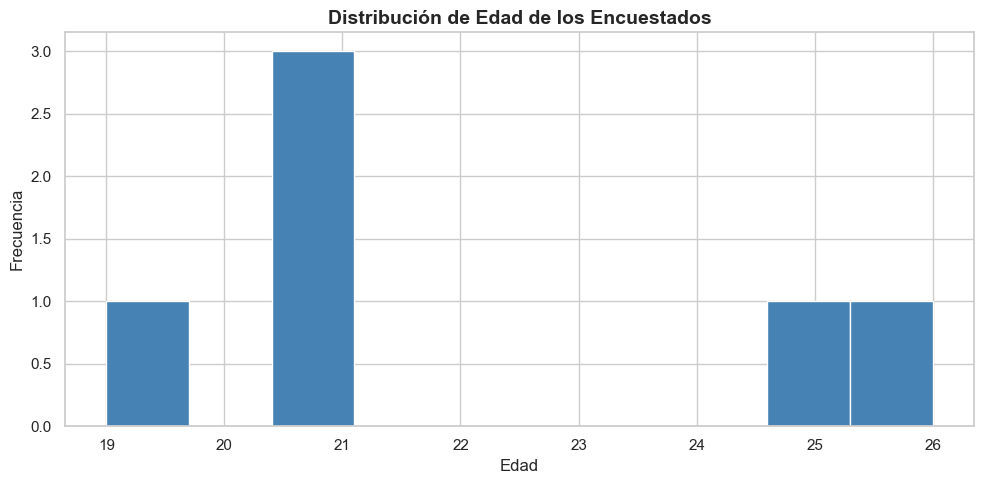

In [28]:
fig, ax = plt.subplots()
ax.hist(df['edad'], bins=10, color='steelblue', edgecolor='white')
ax.set_title('Distribución de Edad de los Encuestados', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('edad.png', dpi=150)
plt.show()

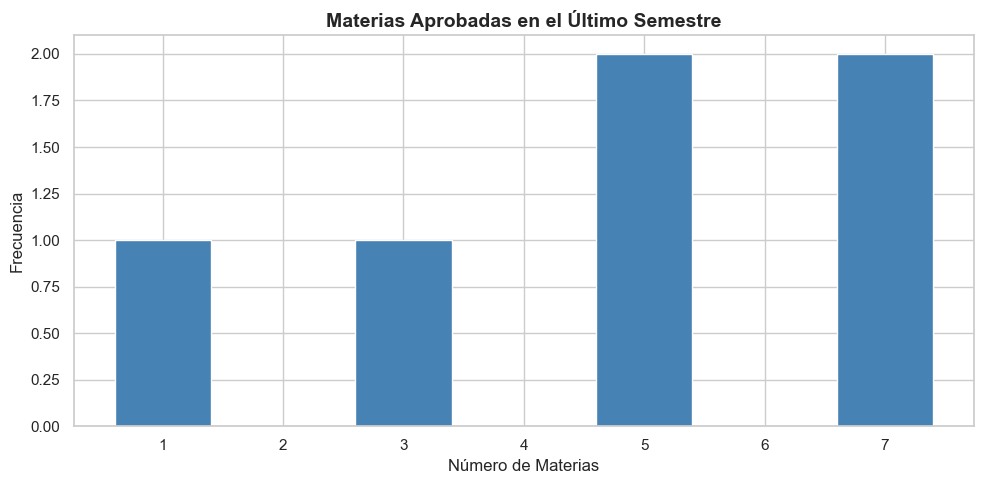

In [29]:
fig, ax = plt.subplots()
conteo = df['materias_aprobadas'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='steelblue', edgecolor='white')
ax.set_title('Materias Aprobadas en el Último Semestre', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Materias')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('materias_aprobadas.png', dpi=150)
plt.show()

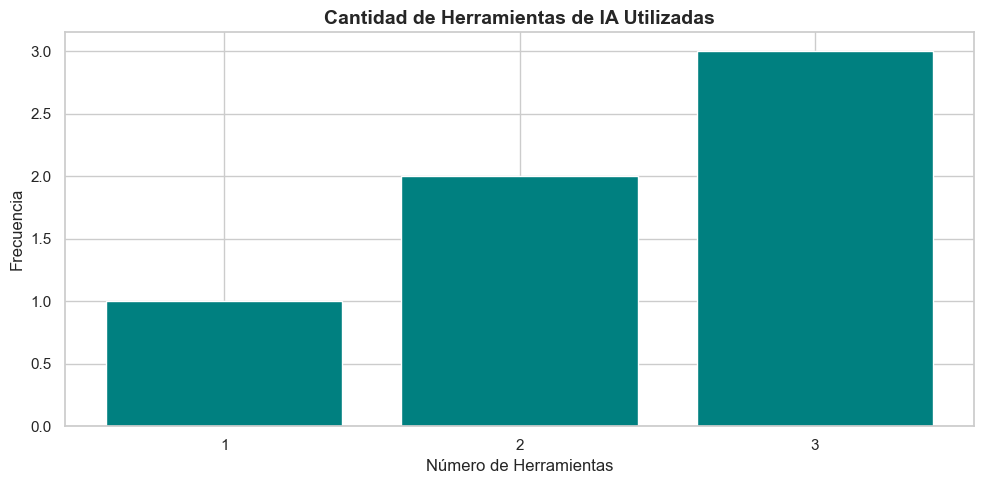

In [30]:
fig, ax = plt.subplots()
conteo = df['num_herramientas'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='teal', edgecolor='white')
ax.set_title('Cantidad de Herramientas de IA Utilizadas', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Herramientas')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('num_herramientas.png', dpi=150)
plt.show()

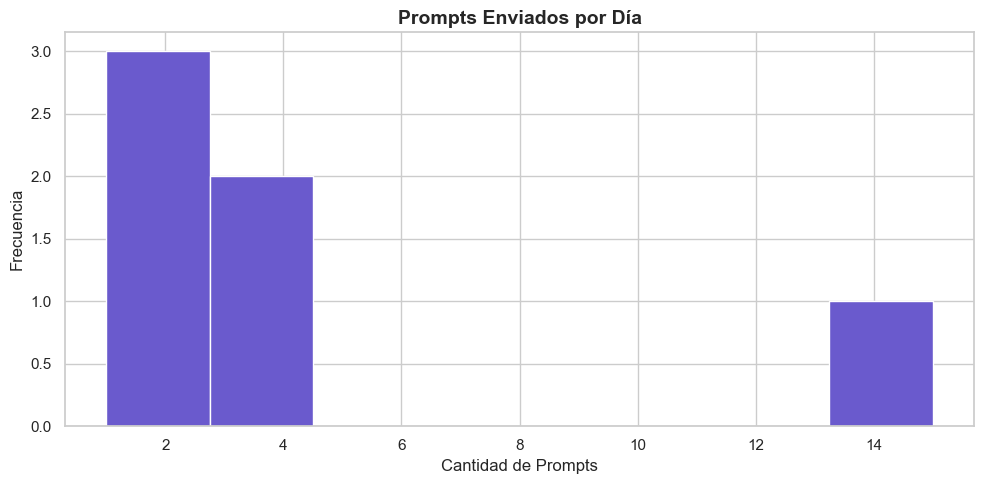

In [31]:
fig, ax = plt.subplots()
ax.hist(df['prompts_dia'], bins=8, color='slateblue', edgecolor='white')
ax.set_title('Prompts Enviados por Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Prompts')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('prompts_dia.png', dpi=150)
plt.show()

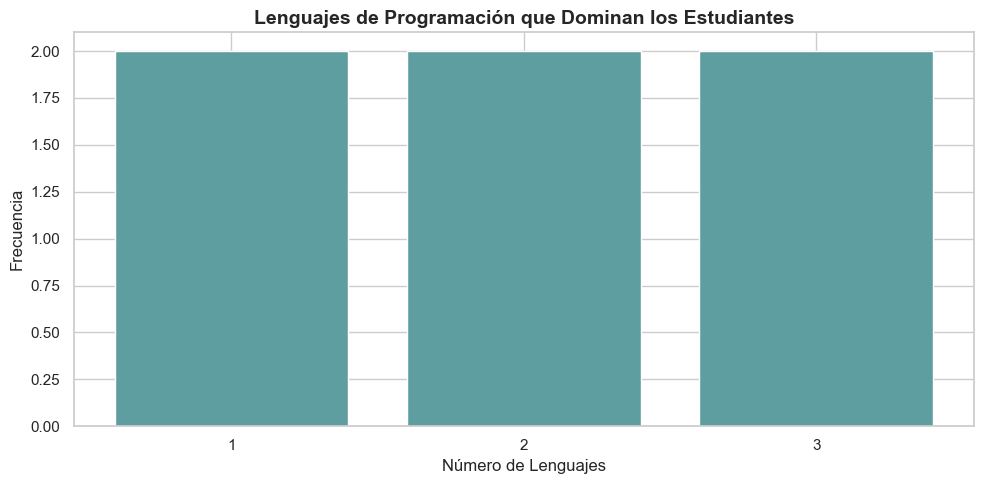

In [32]:
fig, ax = plt.subplots()
conteo = df['num_lenguajes'].value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color='cadetblue', edgecolor='white')
ax.set_title('Lenguajes de Programación que Dominan los Estudiantes', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Lenguajes')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('num_lenguajes.png', dpi=150)
plt.show()

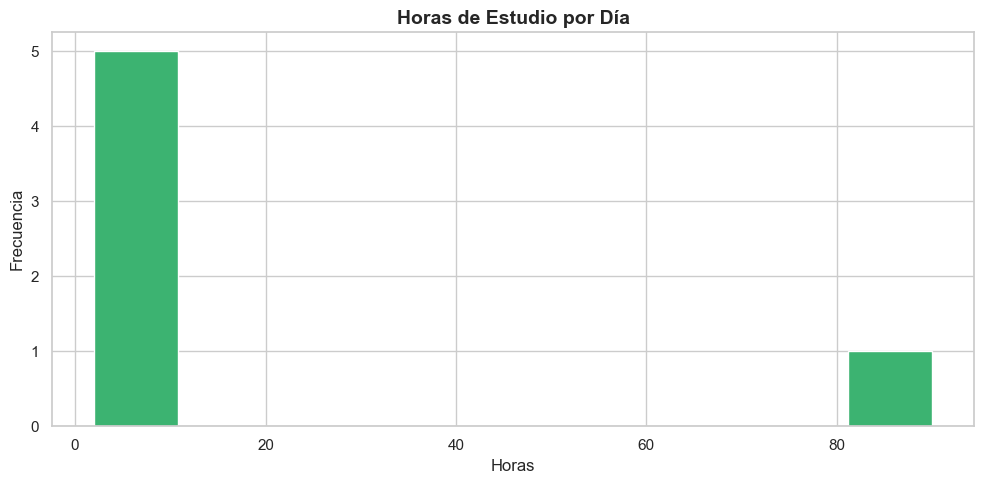

In [33]:
fig, ax = plt.subplots()
ax.hist(df['horas_estudio'], bins=10, color='mediumseagreen', edgecolor='white')
ax.set_title('Horas de Estudio por Día', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('horas_estudio.png', dpi=150)
plt.show()

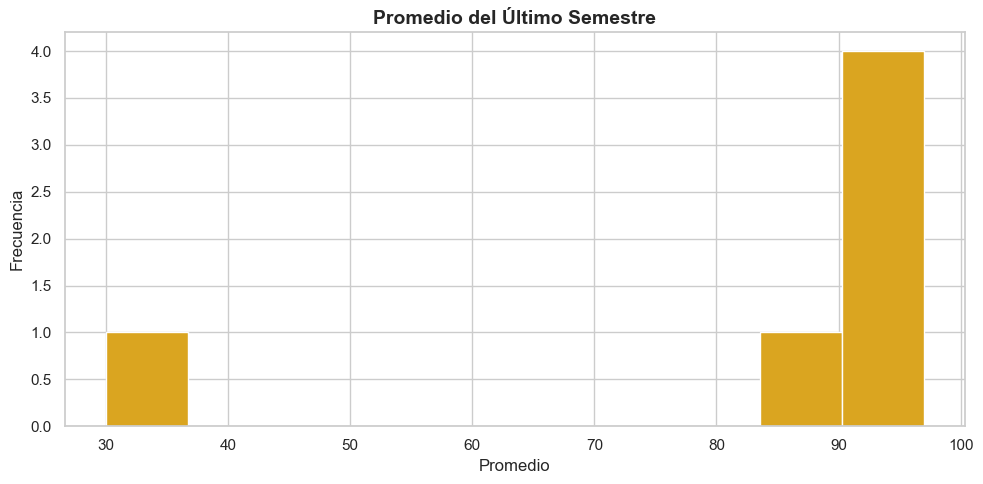

In [34]:
fig, ax = plt.subplots()
ax.hist(df['promedio'], bins=10, color='goldenrod', edgecolor='white')
ax.set_title('Promedio del Último Semestre', fontsize=14, fontweight='bold')
ax.set_xlabel('Promedio')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('promedio.png', dpi=150)
plt.show()


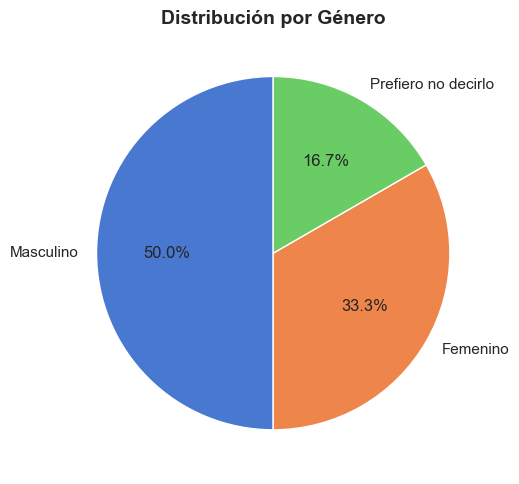

In [35]:
fig, ax = plt.subplots()
conteo = df['genero'].value_counts()
ax.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
       colors=sns.color_palette("muted"), startangle=90)
ax.set_title('Distribución por Género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('genero.png', dpi=150)
plt.show()

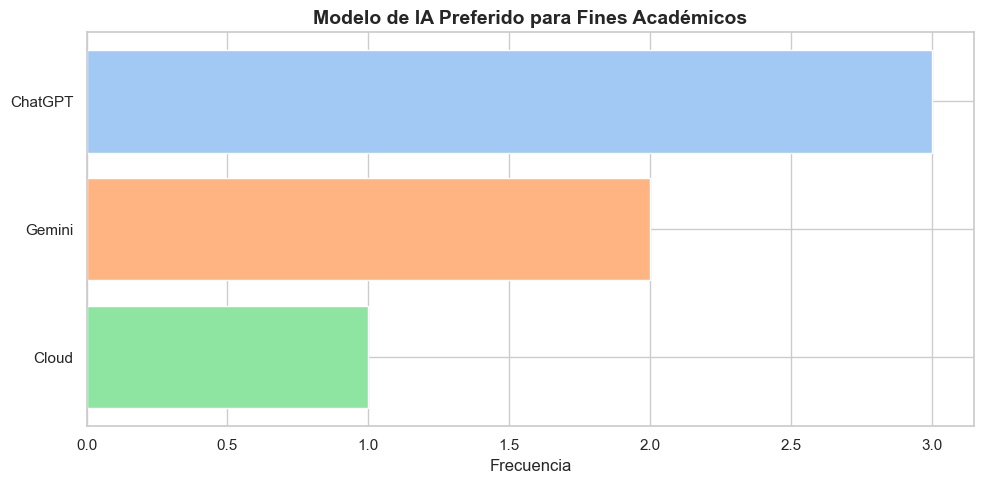

In [38]:
fig, ax = plt.subplots()
conteo = df['modelo_preferido'].value_counts()
ax.barh(conteo.index, conteo.values, color=sns.color_palette("pastel", len(conteo)))
ax.set_title('Modelo de IA Preferido para Fines Académicos', fontsize=14, fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('modelo_preferido.png', dpi=150)
plt.show()

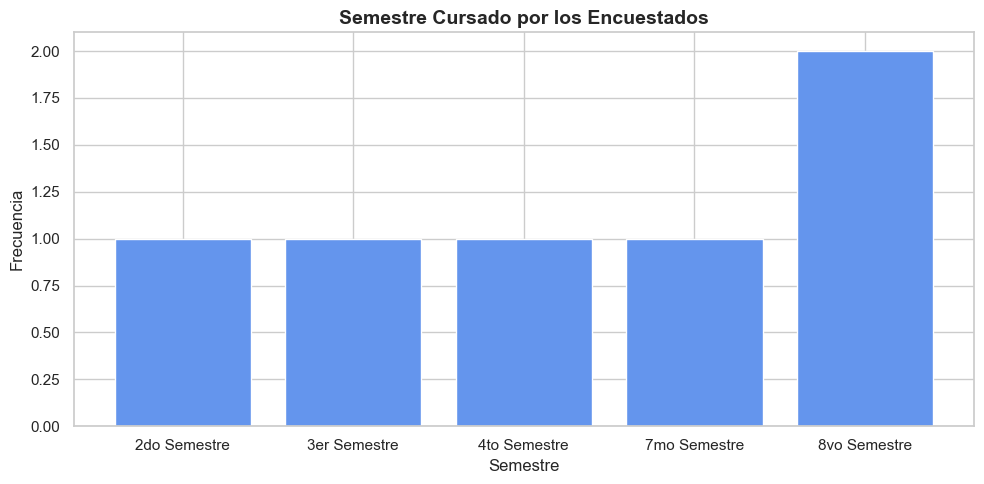

In [39]:
orden_semestre = sorted(df['semestre'].unique())
fig, ax = plt.subplots()
conteo = df['semestre'].value_counts().reindex(orden_semestre)
ax.bar(conteo.index.astype(str), conteo.values, color='cornflowerblue', edgecolor='white')
ax.set_title('Semestre Cursado por los Encuestados', fontsize=14, fontweight='bold')
ax.set_xlabel('Semestre')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('semestre.png', dpi=150)
plt.show()

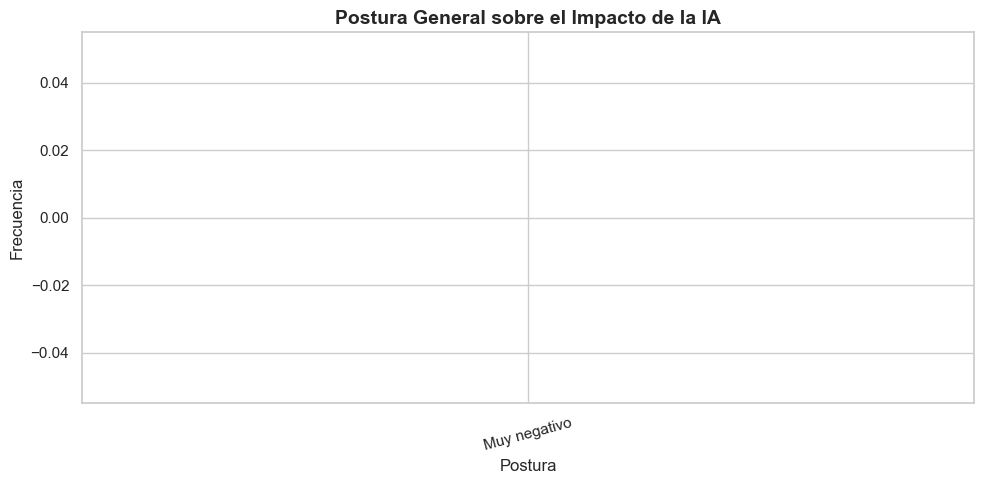

In [40]:
orden_postura = ['Muy negativo', 'Negativo', 'Neutral', 'Positivo', 'Muy positivo']
fig, ax = plt.subplots()
conteo = df['postura_ia'].value_counts().reindex(orden_postura)
ax.bar(conteo.index, conteo.values, color='mediumpurple', edgecolor='white')
ax.set_title('Postura General sobre el Impacto de la IA', fontsize=14, fontweight='bold')
ax.set_xlabel('Postura')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('postura_ia.png', dpi=150)
plt.show()

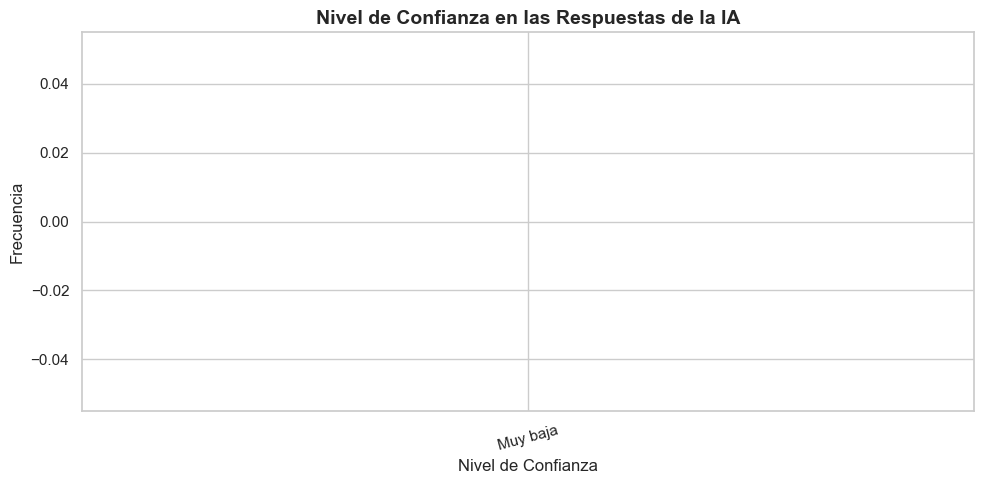

In [41]:
orden_confianza = ['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta']
fig, ax = plt.subplots()
conteo = df['confianza_ia'].value_counts().reindex(orden_confianza)
ax.bar(conteo.index, conteo.values, color='darkorange', edgecolor='white')
ax.set_title('Nivel de Confianza en las Respuestas de la IA', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Confianza')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('confianza_ia.png', dpi=150)
plt.show()

In [42]:
# ── Estadística descriptiva - Variables Cuantitativas ──
cuantitativas = ['edad', 'materias_aprobadas', 'num_herramientas', 
                 'prompts_dia', 'num_lenguajes', 'horas_estudio', 'promedio']

resumen = df[cuantitativas].describe().round(2)
resumen.loc['moda'] = df[cuantitativas].mode().iloc[0]
resumen.loc['varianza'] = df[cuantitativas].var().round(2)

print("📊 Estadística Descriptiva - Variables Cuantitativas")
print(resumen)

📊 Estadística Descriptiva - Variables Cuantitativas
           edad  materias_aprobadas  num_herramientas  prompts_dia  \
count      6.00                6.00              6.00         6.00   
mean      22.17                4.67              2.33         4.17   
std        2.71                2.34              0.82         5.38   
min       19.00                1.00              1.00         1.00   
25%       21.00                3.50              2.00         1.25   
50%       21.00                5.00              2.50         2.50   
75%       24.00                6.50              3.00         3.00   
max       26.00                7.00              3.00        15.00   
moda      21.00                5.00              3.00         1.00   
varianza   7.37                5.47              0.67        28.97   

          num_lenguajes  horas_estudio  promedio  
count              6.00           6.00      6.00  
mean               2.00          18.67     81.67  
std                0.89 